# Olist E-Commerce: Delivery Performance & Revenue Analysis
**Business problem:** where does revenue come from, where do deliveries fail, and is it associated with reviews and repeat purchases?
**Story:** Growth -> Revenue drivers -> Operational leakage -> Customer impact -> Recommendations
Run `python src/clean.py` first (creates data/processed/). Revenue = item price of delivered orders (BRL), freight excluded.

In [1]:
import os, numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportion_confint
if os.getcwd().endswith("notebooks"): os.chdir("..")
os.makedirs("reports/figures", exist_ok=True)
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110
def save(name): plt.tight_layout(); plt.savefig(f"reports/figures/{name}.png"); plt.show()

## 1. Data loading and quality checks (raw files)

In [2]:
R="data/raw/"
raw={n:pd.read_csv(R+f) for n,f in {"orders":"olist_orders_dataset.csv","items":"olist_order_items_dataset.csv","reviews":"olist_order_reviews_dataset.csv",
     "customers":"olist_customers_dataset.csv","products":"olist_products_dataset.csv","sellers":"olist_sellers_dataset.csv","payments":"olist_order_payments_dataset.csv"}.items()}
for n,df in raw.items():
    nl=df.isnull().sum(); print(f"{n:10s} shape={df.shape} duplicate_rows={df.duplicated().sum()} nulls={nl[nl>0].to_dict()}")
print(raw["orders"].order_status.value_counts())
print("reviews: orders with >1 review =",(raw["reviews"].groupby("order_id").size()>1).sum())
print("customer_id vs customer_unique_id:",raw["customers"].customer_id.nunique(),raw["customers"].customer_unique_id.nunique())

orders     shape=(99441, 8) duplicate_rows=0 nulls={'order_approved_at': 160, 'order_delivered_carrier_date': 1783, 'order_delivered_customer_date': 2965}
items      shape=(112650, 7) duplicate_rows=0 nulls={}


reviews    shape=(99224, 7) duplicate_rows=0 nulls={'review_comment_title': 87656, 'review_comment_message': 58247}
customers  shape=(99441, 5) duplicate_rows=0 nulls={}
products   shape=(32951, 9) duplicate_rows=0 nulls={'product_category_name': 610, 'product_name_lenght': 610, 'product_description_lenght': 610, 'product_photos_qty': 610, 'product_weight_g': 2, 'product_length_cm': 2, 'product_height_cm': 2, 'product_width_cm': 2}
sellers    shape=(3095, 4) duplicate_rows=0 nulls={}
payments   shape=(103886, 5) duplicate_rows=0 nulls={}
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


reviews: orders with >1 review = 547
customer_id vs customer_unique_id: 99441 96096


## 2. Cleaning decisions (Problem -> Decision -> Reason) are implemented in `src/clean.py`
- Multiple reviews per order -> keep latest -> one score per order, no join duplication
- `customer_id` changes per order -> use `customer_unique_id` for repeat/cohort -> otherwise repeat rate is ~0
- Null category (610 products) -> label `unknown`, no imputation
- Undelivered orders have no delivery date -> delay metrics only for delivered orders
- Canceled/unavailable orders have no items -> excluded from revenue

In [3]:
o=pd.read_csv("data/processed/orders_clean.csv",parse_dates=["order_month","order_purchase_timestamp"])
items=pd.read_csv("data/processed/order_items_clean.csv")
prod=pd.read_csv("data/processed/products_clean.csv"); sell=pd.read_csv("data/processed/sellers_clean.csv")
d=o[o.is_delivered].copy(); d["revenue"]=d.items_revenue
print("delivered orders:",len(d)," revenue:",round(d.revenue.sum(),2))
# Feature check: delivery_days, delay_days, late_flag, order_month, freight_to_price_ratio (item level)
print(d[["delivery_days","delay_days","late_flag"]].describe().round(2))
print("freight_to_price_ratio median:",round(items.freight_to_price_ratio.median(),3))
win=d[(d.order_month>="2017-01-01")&(d.order_month<="2018-08-01")]   # reliable window

delivered orders: 96470  revenue: 13220248.93
       delivery_days  delay_days  late_flag
count       96470.00    96470.00   96470.00
mean           12.56      -11.18       0.08
std             9.55       10.18       0.27
min             0.53     -146.02       0.00
25%             6.77      -16.24       0.00
50%            10.22      -11.95       0.00
75%            15.72       -6.39       0.00
max           209.63      188.98       1.00
freight_to_price_ratio median: 0.231


## 3. Growth: monthly revenue and orders

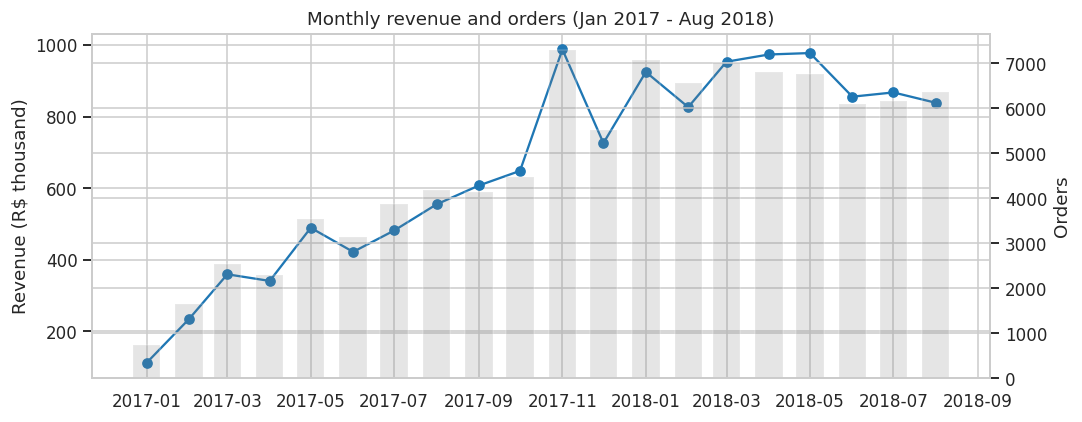

Jan-Aug YoY: revenue +141.1%, orders +139.9%, AOV +0.5% (R$136.08 -> R$136.75)


In [4]:
m=win.groupby("order_month").agg(revenue=("revenue","sum"),orders=("order_id","count"),aov=("revenue","mean"))
fig,ax=plt.subplots(figsize=(10,4)); ax.plot(m.index,m.revenue/1e3,marker="o",color="#1f77b4"); ax.set_ylabel("Revenue (R$ thousand)")
ax2=ax.twinx(); ax2.bar(m.index,m.orders,width=20,alpha=.2,color="grey"); ax2.set_ylabel("Orders"); ax.set_title("Monthly revenue and orders (Jan 2017 - Aug 2018)")
save("01_monthly_revenue_orders")
a=win[win.order_month<="2017-08-01"]; b=win[win.order_month>="2018-01-01"]
print(f"Jan-Aug YoY: revenue {b.revenue.sum()/a.revenue.sum()-1:+.1%}, orders {len(b)/len(a)-1:+.1%}, AOV {b.revenue.mean()/a.revenue.mean()-1:+.1%} (R${a.revenue.mean():.2f} -> R${b.revenue.mean():.2f})")

## 4. Revenue drivers: categories and states

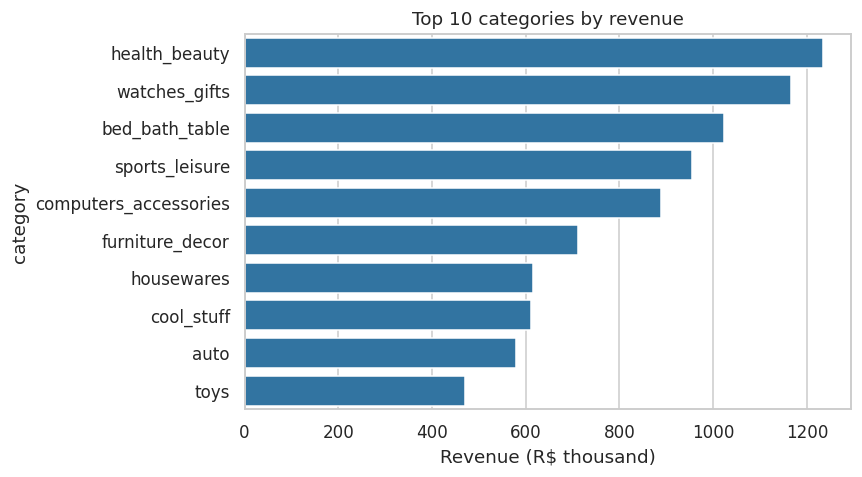

top-5 category share %: 39.8 | top-10: 62.4


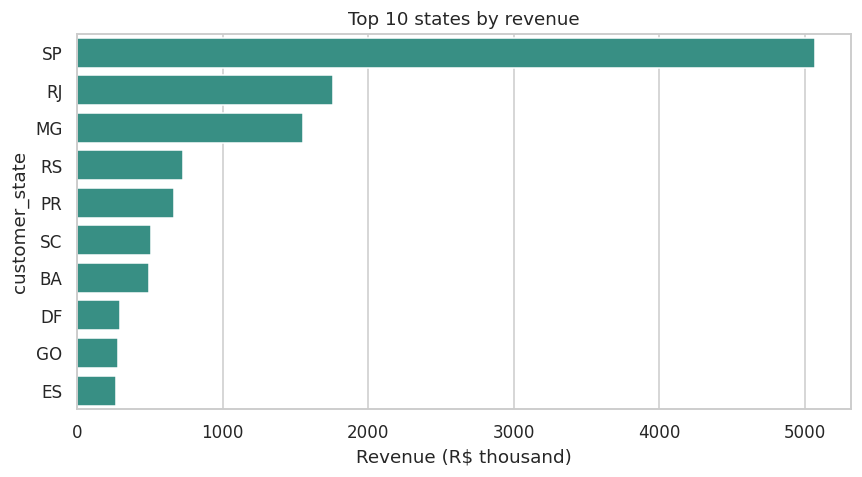

                  revenue  orders  share
customer_state                          
SP              5066563.0   40494   38.3
RJ              1759651.1   12350   13.3
MG              1552481.8   11354   11.7
RS               728718.5    5344    5.5
PR               666063.5    4923    5.0
SP+RJ+MG share %: 63.4


In [5]:
s=items.merge(d[["order_id","customer_state"]],on="order_id").merge(prod[["product_id","category"]],on="product_id")
cat=s.groupby("category").price.sum().sort_values(ascending=False); share=cat/cat.sum()*100
fig,ax=plt.subplots(figsize=(8,4.5)); sns.barplot(x=cat.head(10)/1e3,y=cat.head(10).index,color="#1f77b4",ax=ax); ax.set_xlabel("Revenue (R$ thousand)"); ax.set_title("Top 10 categories by revenue")
save("02_top_categories"); print("top-5 category share %:",round(share.head(5).sum(),1),"| top-10:",round(share.head(10).sum(),1))
st=d.groupby("customer_state").agg(revenue=("revenue","sum"),orders=("order_id","count")).sort_values("revenue",ascending=False)
st["share"]=st.revenue/st.revenue.sum()*100
fig,ax=plt.subplots(figsize=(8,4.5)); sns.barplot(x=st.head(10).revenue/1e3,y=st.head(10).index,color="#2a9d8f",ax=ax); ax.set_xlabel("Revenue (R$ thousand)"); ax.set_title("Top 10 states by revenue")
save("03_top_states"); print(st.head(5).round(1)); print("SP+RJ+MG share %:",round(st.loc[["SP","RJ","MG"],"share"].sum(),1))

## 5. Operational leakage: delivery time and lateness

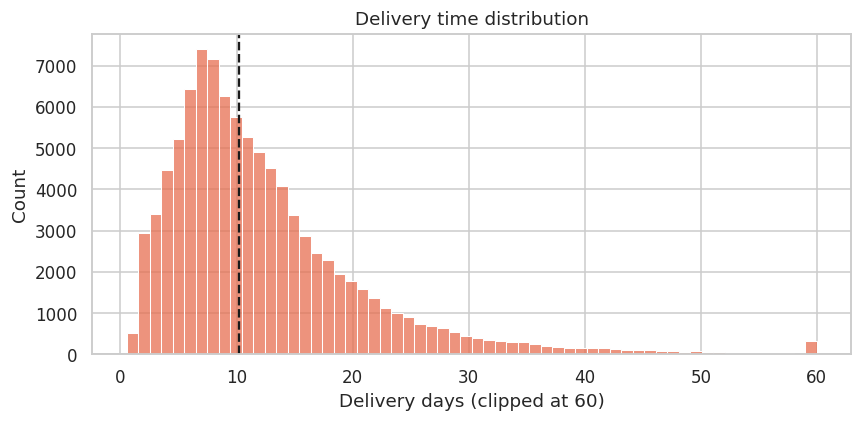

median 10.2 p90 23.1 p99 46.1 | >30 days: 4.72 %
estimated-vs-actual: median promised days 23.0


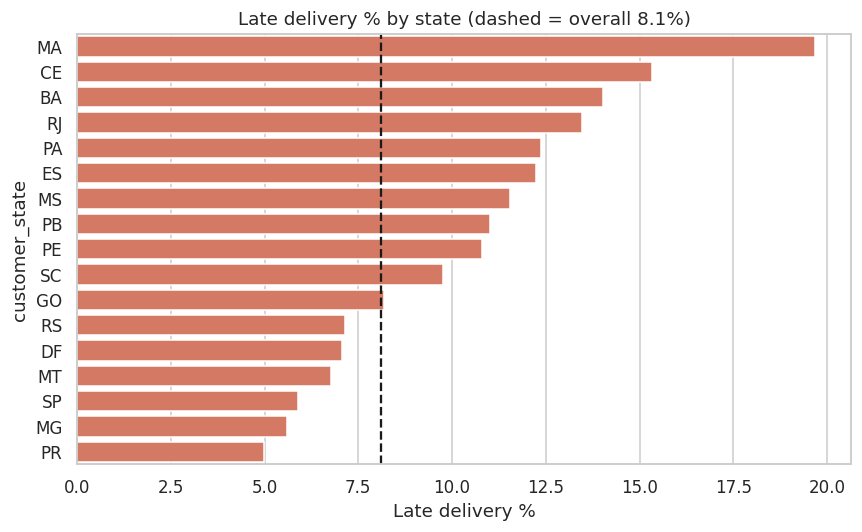

                orders  late_pct  late_orders  median_days
customer_state                                            
MA                 717     19.67        141.0        19.19
CE                1279     15.32        196.0        18.21
BA                3256     14.04        457.0        16.91
RJ               12350     13.47       1664.0        12.04
PA                 946     12.37        117.0        21.08
ES                1995     12.23        244.0        13.64
excess late orders vs SP-rate benchmark (top 5):
 customer_state
RJ    936.0
BA    265.0
SC    137.0
ES    126.0
CE    121.0
dtype: float64
share of all late orders from RJ+BA+MA+CE: 31.4 %


In [6]:
fig,ax=plt.subplots(figsize=(8,4)); sns.histplot(d.delivery_days.clip(upper=60),bins=60,color="#e76f51",ax=ax)
ax.axvline(d.delivery_days.median(),color="k",ls="--"); ax.set_xlabel("Delivery days (clipped at 60)"); ax.set_title("Delivery time distribution")
save("04_delivery_time_hist")
print("median",round(d.delivery_days.median(),1),"p90",round(d.delivery_days.quantile(.9),1),"p99",round(d.delivery_days.quantile(.99),1),"| >30 days:",round((d.delivery_days>30).mean()*100,2),"%")
print("estimated-vs-actual: median promised days",round(((pd.to_datetime(o.loc[d.index,'order_estimated_delivery_date'])-d.order_purchase_timestamp).dt.days).median(),1))
ls=d.groupby("customer_state").agg(orders=("order_id","count"),late_pct=("late_flag",lambda x:x.mean()*100),late_orders=("late_flag","sum"),median_days=("delivery_days","median"))
ls=ls[ls.orders>=500].sort_values("late_pct",ascending=False); overall=d.late_flag.mean()*100
fig,ax=plt.subplots(figsize=(8,5)); sns.barplot(x=ls.late_pct,y=ls.index,color="#e76f51",ax=ax); ax.axvline(overall,color="k",ls="--"); ax.set_xlabel("Late delivery %"); ax.set_title(f"Late delivery % by state (dashed = overall {overall:.1f}%)")
save("05_late_pct_by_state"); print(ls.round(2).head(6))
excess=(ls.late_orders-ls.orders*ls.loc["SP","late_pct"]/100).clip(lower=0).sort_values(ascending=False)
print("excess late orders vs SP-rate benchmark (top 5):\n",excess.head(5).round(0)); print("share of all late orders from RJ+BA+MA+CE:",round(ls.loc[["RJ","BA","MA","CE"],"late_orders"].sum()/d.late_flag.sum()*100,1),"%")

## 6. Sellers

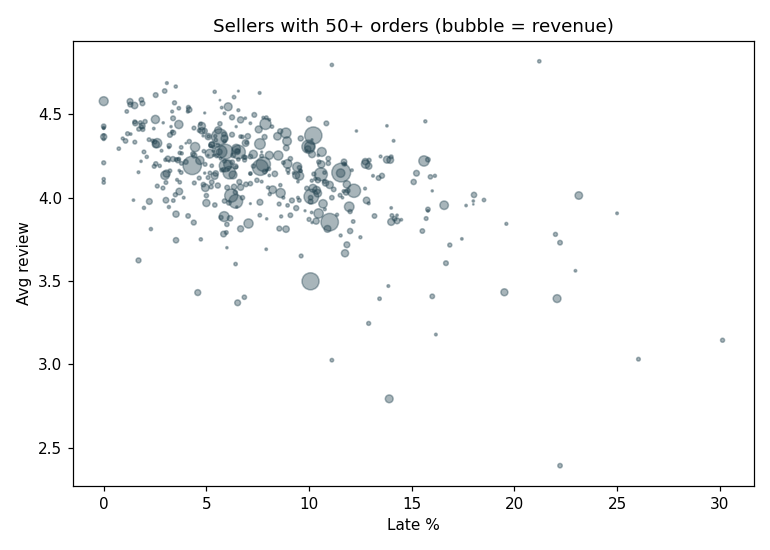

sellers 50+ orders: 425 | corr(late%,avg review)= -0.50 | sellers >15% late: 35 with revenue share of these 50+ sellers %: 5.5
top 10% sellers share of seller revenue % (all sellers): 67.1


In [7]:
sd=items.merge(d[["order_id","late_flag","review_score"]],on="order_id")
seller_order=sd.groupby(["seller_id","seller_state","order_id"],as_index=False).agg(revenue=("price","sum"),late_flag=("late_flag","first"),review_score=("review_score","first"))
sp=seller_order.groupby(["seller_id","seller_state"]).agg(orders=("order_id","nunique"),revenue=("revenue","sum"),late_pct=("late_flag",lambda x:x.mean()*100),avg_review=("review_score","mean")).query("orders>=50")
fig,ax=plt.subplots(figsize=(7,5)); ax.scatter(sp.late_pct,sp.avg_review,s=sp.revenue/1500,alpha=.4,color="#264653"); ax.set_xlabel("Late %"); ax.set_ylabel("Avg review"); ax.set_title("Sellers with 50+ orders (bubble = revenue)")
save("06_seller_late_vs_review")
print("sellers 50+ orders:",len(sp),"| corr(late%,avg review)=",round(sp.late_pct.corr(sp.avg_review),2),"| sellers >15% late:",(sp.late_pct>15).sum(),"with revenue share of these 50+ sellers %:",round(sp[sp.late_pct>15].revenue.sum()/sp.revenue.sum()*100,1))
print("top 10% sellers share of seller revenue % (all sellers):",round(seller_order.groupby('seller_id').revenue.sum().sort_values(ascending=False).head(int(seller_order.seller_id.nunique()*.1)).sum()/seller_order.revenue.sum()*100,1))


## 7. Customer impact: reviews and repeat purchase (with statistics)

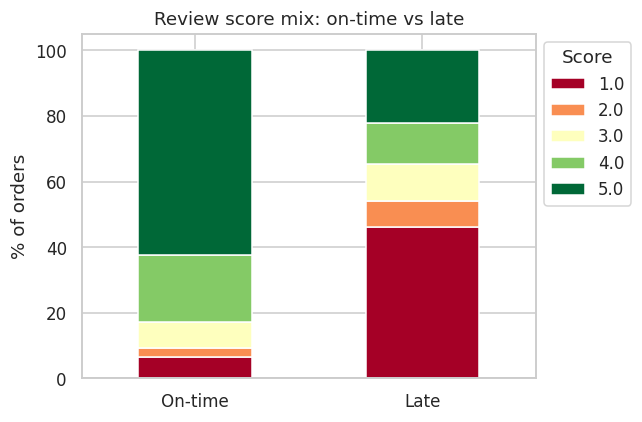

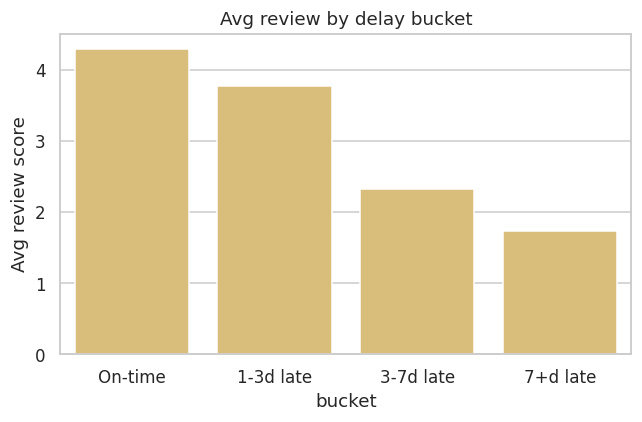

           count  mean
bucket                
On-time    88162  4.29
1-3d late   2637  3.77
3-7d late   1773  2.32
7+d late    3252  1.73
STAT1 Mann-Whitney U=150,706,850, p=0 (p<1e-300 means underflow, i.e. effectively 0); n_late=7,661, n_ontime=88,163
means late 2.57 vs on-time 4.29; medians 2.0 vs 5.0; rank-biserial r=-0.55; 1-star: 46.2% vs 6.6%


STAT2 contingency (rows late_flag 0/1, cols repeat 0/1):
 repeat         0     1
late_flag             
0.0        49447  2082
1.0         4237   139
chi2=7.89, dof=1, p=0.0050; repeat rate on-time first order 4.04% vs late 3.18%
STAT3 late rate 8.11% (95% CI 7.94% - 8.29%), 7,826 of 96,470


In [8]:
r=d.dropna(subset=["review_score"]); late=r[r.late_flag==1].review_score; ont=r[r.late_flag==0].review_score
dist=r.groupby("late_flag").review_score.value_counts(normalize=True).unstack()*100
dist.index=["On-time","Late"]; dist.plot(kind="bar",stacked=True,figsize=(6,4),colormap="RdYlGn"); plt.ylabel("% of orders"); plt.title("Review score mix: on-time vs late"); plt.legend(title="Score",bbox_to_anchor=(1,1)); plt.xticks(rotation=0)
save("07_review_by_lateness")
d["bucket"]=pd.cut(d.delay_days,[-1000,-1e-4,3,7,1000],labels=["On-time","1-3d late","3-7d late","7+d late"])
bk=d.dropna(subset=["review_score"]).groupby("bucket",observed=True).review_score.agg(["count","mean"]).round(2)
fig,ax=plt.subplots(figsize=(6,4)); sns.barplot(x=bk.index,y=bk["mean"],color="#e9c46a",ax=ax); ax.set_ylabel("Avg review score"); ax.set_title("Avg review by delay bucket")
save("08_review_by_delay_bucket"); print(bk)
# Stat 1: Mann-Whitney U (ordinal, skewed 1-5 scores -> no normality assumption)
u=stats.mannwhitneyu(late,ont,alternative="two-sided"); auc=u.statistic/(len(late)*len(ont))
print(f"STAT1 Mann-Whitney U={u.statistic:,.0f}, p={u.pvalue:.3g} (p<1e-300 means underflow, i.e. effectively 0); n_late={len(late):,}, n_ontime={len(ont):,}")
print(f"means late {late.mean():.2f} vs on-time {ont.mean():.2f}; medians {late.median()} vs {ont.median()}; rank-biserial r={2*auc-1:.2f}; 1-star: {(late==1).mean():.1%} vs {(ont==1).mean():.1%}")
# Stat 2: chi-square, first-order lateness vs later repeat purchase (customers with >=180 days of follow-up)
d2=d.sort_values("order_purchase_timestamp"); cnt=d2.groupby("customer_unique_id").size()
first=d2.groupby("customer_unique_id").head(1).set_index("customer_unique_id")
coh=first[first.order_purchase_timestamp<=d2.order_purchase_timestamp.max()-pd.Timedelta(days=180)].copy(); coh["repeat"]=(cnt.reindex(coh.index)>1).astype(int)
ct=pd.crosstab(coh.late_flag,coh["repeat"]); chi=stats.chi2_contingency(ct,correction=False)
print("STAT2 contingency (rows late_flag 0/1, cols repeat 0/1):\n",ct); print(f"chi2={chi[0]:.2f}, dof={chi[2]}, p={chi[1]:.4f}; repeat rate on-time first order {coh[coh.late_flag==0]['repeat'].mean():.2%} vs late {coh[coh.late_flag==1]['repeat'].mean():.2%}")
# Stat 3: Wilson 95% CI for late rate
k,n=int(d.late_flag.sum()),len(d); lo,hi=proportion_confint(k,n,method="wilson"); print(f"STAT3 late rate {k/n:.2%} (95% CI {lo:.2%} - {hi:.2%}), {k:,} of {n:,}")

## 8. Repeat purchase and cohort retention

customers 93,350; repeat 2,801 = 3.00%; max orders by one customer 15


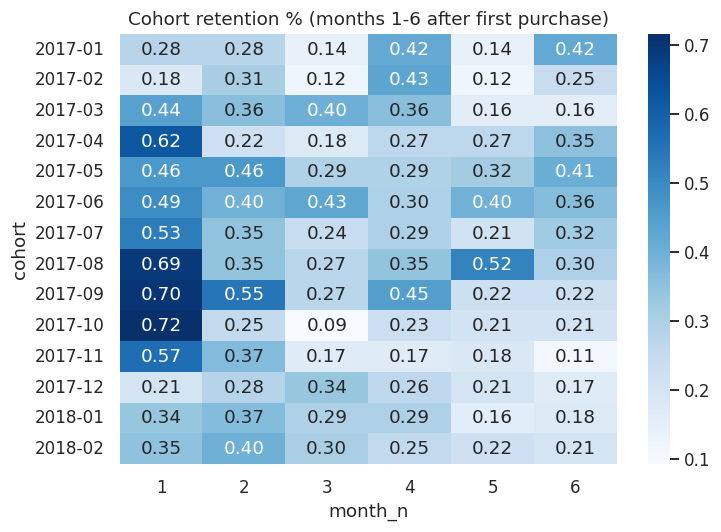

avg month-1 retention over cohorts %: 0.47 | max cell %: 0.72
share of monthly orders from returning customers (mean Jan17-Aug18) %: 1.7


In [9]:
per=d.groupby("customer_unique_id").order_id.nunique(); print(f"customers {len(per):,}; repeat {int((per>1).sum()):,} = {(per>1).mean():.2%}; max orders by one customer {per.max()}")
d["cohort"]=d.groupby("customer_unique_id").order_month.transform("min")
d["month_n"]=((d.order_month.dt.year-d.cohort.dt.year)*12+(d.order_month.dt.month-d.cohort.dt.month))
act=d.groupby(["cohort","month_n"]).customer_unique_id.nunique().reset_index(name="active")
size=d.groupby("cohort").customer_unique_id.nunique().rename("size"); act=act.join(size,on="cohort"); act["ret"]=act.active/act["size"]*100
hm=act[(act.cohort>="2017-01-01")&(act.cohort<="2018-02-01")&(act.month_n.between(1,6))].pivot(index="cohort",columns="month_n",values="ret")
hm.index=hm.index.strftime("%Y-%m")
fig,ax=plt.subplots(figsize=(7,5)); sns.heatmap(hm,annot=True,fmt=".2f",cmap="Blues",ax=ax); ax.set_title("Cohort retention % (months 1-6 after first purchase)")
save("09_cohort_retention"); print("avg month-1 retention over cohorts %:",round(hm[1].mean(),2),"| max cell %:",round(hm.max().max(),2))
newrep=d.assign(is_first=d.order_month==d.cohort).groupby("order_month").is_first.mean()
print("share of monthly orders from returning customers (mean Jan17-Aug18) %:",round((1-newrep.loc['2017-01-01':'2018-08-01']).mean()*100,1))

## 9. Export tables for Power BI

In [10]:
os.makedirs("data/powerbi",exist_ok=True)
d["customer_type_first"]=np.where(d.order_month==d.cohort,"New","Returning")
d[["order_id","order_purchase_timestamp","order_month","customer_unique_id","customer_state","revenue","freight","n_items","delivery_days","delay_days","late_flag","review_score","bucket","customer_type_first","cohort"]].to_csv("data/powerbi/orders.csv",index=False)
s2=items.merge(d[["order_id","order_month","customer_state","late_flag","review_score"]],on="order_id").merge(prod[["product_id","category"]],on="product_id").merge(sell[["seller_id","seller_state"]],on="seller_id")
s2[["order_id","order_item_id","order_month","customer_state","seller_id","seller_state","category","price","freight_value","late_flag","review_score"]].to_csv("data/powerbi/order_items.csv",index=False)
act[(act.month_n<=12)].to_csv("data/powerbi/cohort_retention.csv",index=False)
sp.reset_index().to_csv("data/powerbi/sellers_50plus.csv",index=False)
print("exported:",os.listdir("data/powerbi"))

exported: ['sellers_50plus.csv', 'orders.csv', 'cohort_retention.csv', 'order_items.csv']
